In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load the WDBC dataset
df = pd.read_csv('/content/wdbc.data', header=None)

# Give column names
columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean',
    'fractal_dimension_mean',

    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
    'fractal_dimension_se',

    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst',
    'fractal_dimension_worst'
]

df.columns = columns


# 1. Display first 5 rows
print("FIRST 5 ROWS")
print(df.head())


# 2. Display dataset shape
print("\nDATASET SHAPE")
print(df.shape)


# 3. Display column names
print("\nCOLUMN NAMES")
print(df.columns)


# 4. Display data types
print("\nDATA TYPES")
print(df.dtypes)


# 5. Display dataset information
print("\nDATASET INFORMATION")
df.info()


# 6. Display statistical summary
print("\nSTATISTICAL SUMMARY")
print(df.describe())


# 7. Check missing values
print("\nMISSING VALUES")
print(df.isnull().sum())


# 8. Check duplicate rows
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())


# 9. Diagnosis distribution
print("\nDIAGNOSIS DISTRIBUTION")
print(df['diagnosis'].value_counts())


# 10. Diagnosis percentage
print("\nDIAGNOSIS PERCENTAGE")
print(df['diagnosis'].value_counts(normalize=True) * 100)

FIRST 5 ROWS
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_wo

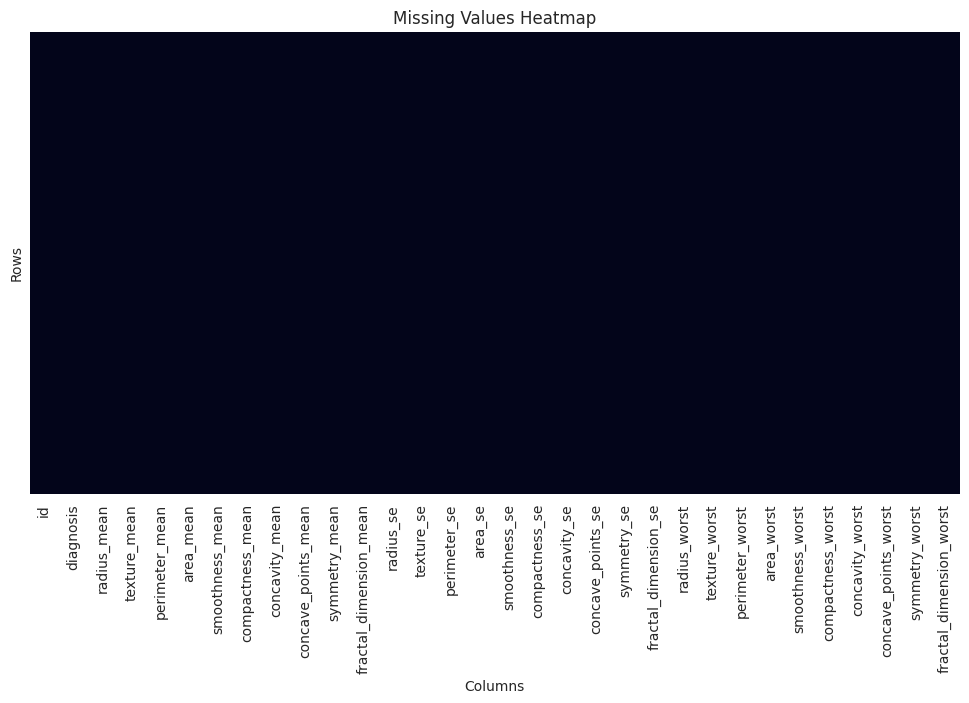

In [2]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

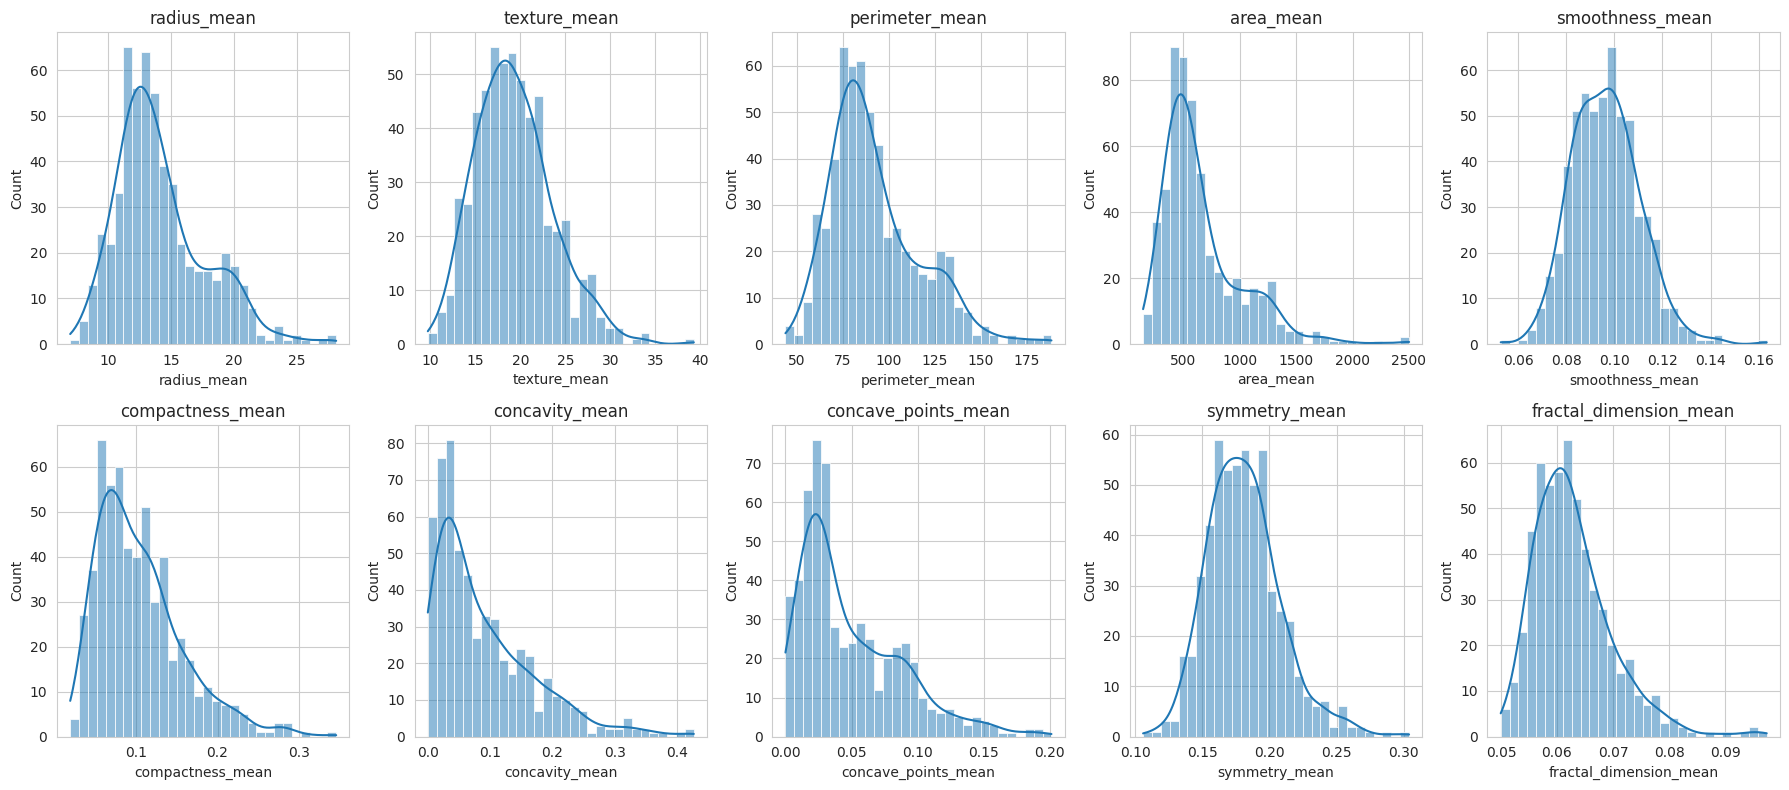

In [3]:
mean_cols = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave_points_mean',
    'symmetry_mean',
    'fractal_dimension_mean'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(mean_cols):
    row, colpos = divmod(i, 5)

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, colpos])

    axes[row, colpos].set_title(col)

plt.tight_layout()
plt.show()

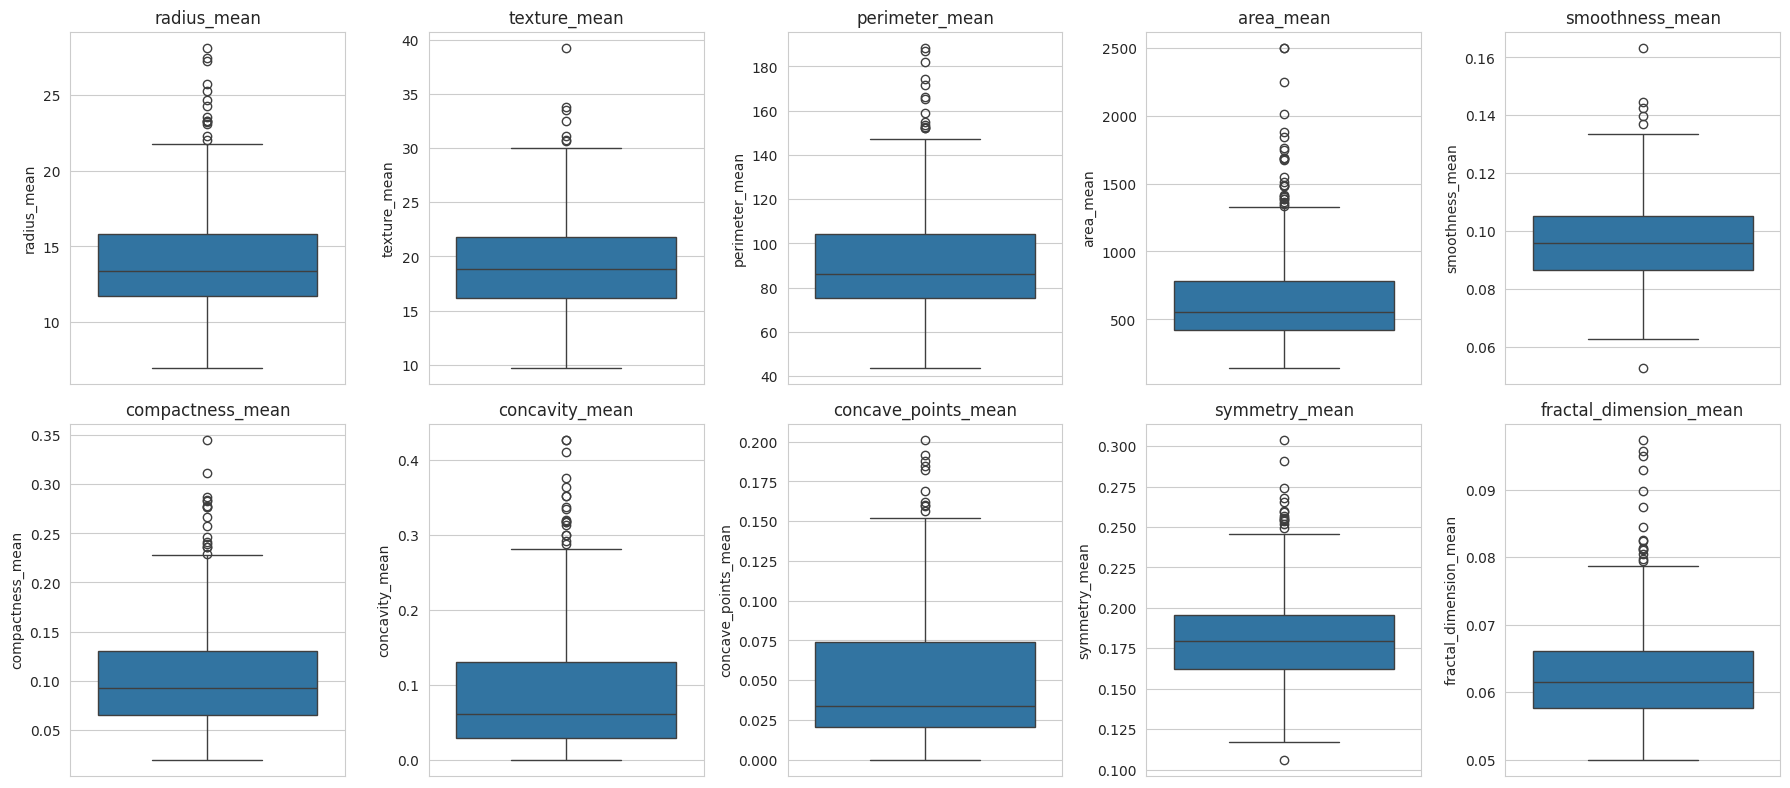

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(mean_cols):
    row, colpos = divmod(i, 5)

    sns.boxplot(y=df[col], ax=axes[row, colpos])

    axes[row, colpos].set_title(col)

plt.tight_layout()
plt.show()

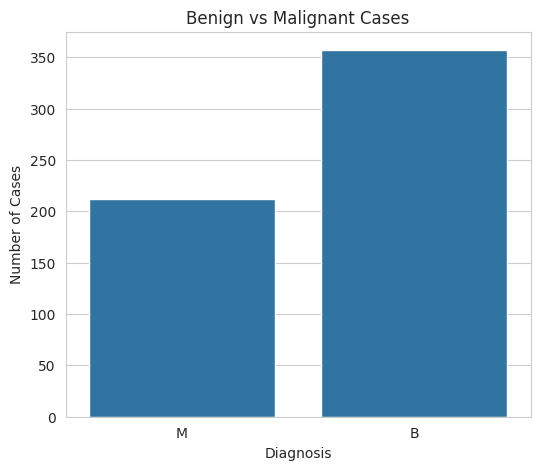

In [5]:
plt.figure(figsize=(6, 5))

sns.countplot(x='diagnosis', data=df)

plt.title("Benign vs Malignant Cases")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Cases")

plt.show()

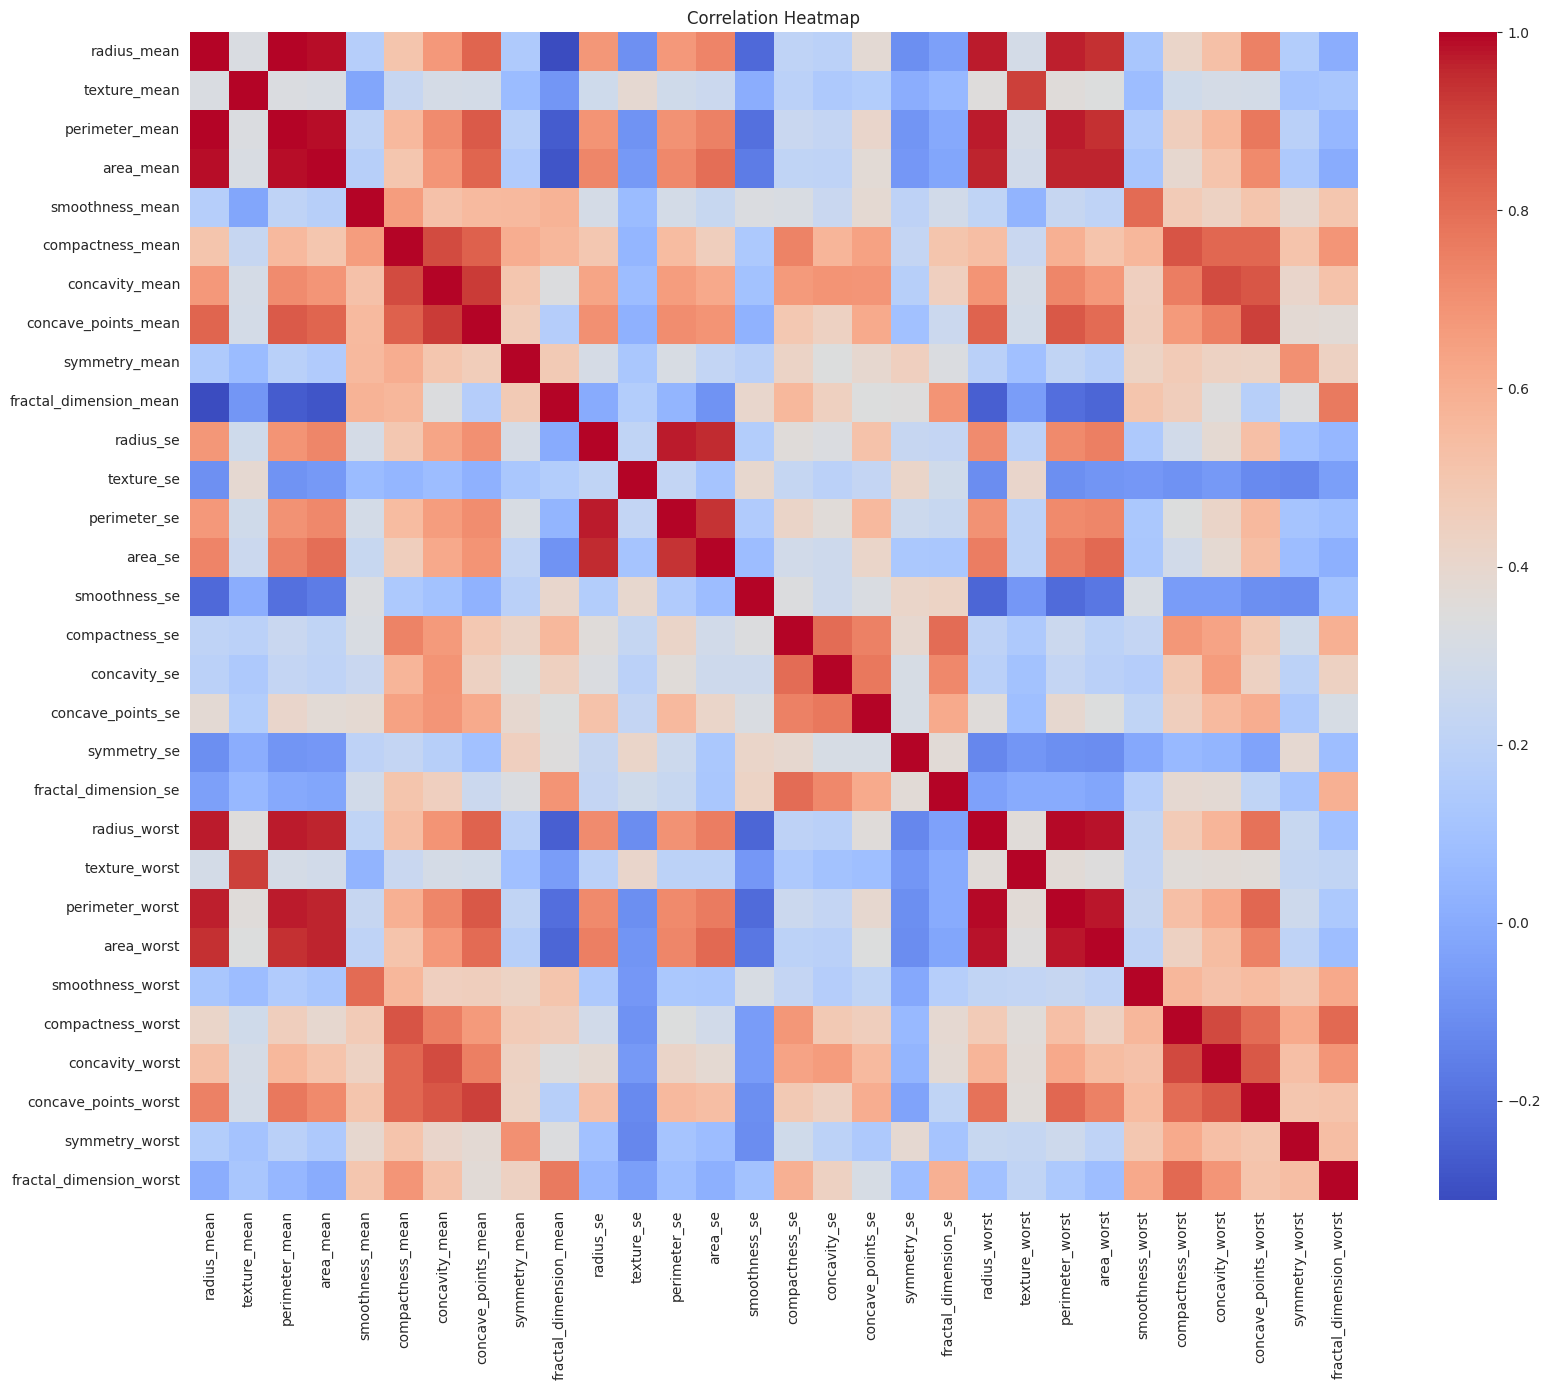

In [6]:
numeric_df = df.drop(columns=['id', 'diagnosis'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    square=True
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()